# Part 04: Ice Phenology Correlation Analysis

**Goal:** Analyze relationships between ice phenology metrics and lake characteristics

**Key Questions:**
1. How does latitude affect ice-on and ice-off timing?
2. Does lake size (area) influence ice-free duration?
3. Do lake shape metrics (circularity, SDI, convexity) correlate with phenology?
4. What is the inter-annual variability (2019-2023)?
5. Are there spatial patterns or regional clusters?

**Input Data:**
- `alaska_lakes_ice_phenology_2019-2023.csv` - Phenology summary with morphometry

**Outputs:**
- Correlation matrices and scatter plots
- Maps showing spatial patterns
- Inter-annual comparison plots
- Statistical summaries by latitude bands

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Specific warning suppressions instead of blanket ignore
warnings.filterwarnings('ignore', category=FutureWarning, module='google.api_core')
warnings.filterwarnings('ignore', category=FutureWarning, module='pyproj')
warnings.filterwarnings('ignore', message='.*Shapely GEOS.*')

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Output paths
FIGURES_DIR = './figures'
RESULTS_GCS = 'gs://wustl-eeps-geospatial/thermokarst_lakes/results'

print("Libraries loaded successfully")

## Part 1: Load Phenology Data

In [ ]:
# Load phenology results - using local data from first_550
# (Full GCS export from notebook 03 not available)

phenology_path = './first_550/alaska_lakes_ice_events_multisensor_2024.csv'
geometry_path = './first_550/alaska_lake_geometries.csv'

# Load phenology events
events = pd.read_csv(phenology_path)

# Load geometry data
geometry = pd.read_csv(geometry_path)

# Merge phenology with geometry
df = events.merge(geometry[['lake_id', 'circularity', 'convexity', 'fractal_dim', 'lake_perim_m']], 
                  on='lake_id', how='left')

# Rename columns to match expected format
df = df.rename(columns={
    'first_no_ice_doy': 'ice_off_doy',
    'first_full_ice_doy': 'ice_on_doy',
    'lake_area_m2': 'area_m2',
})

# DOY validation: Check for invalid values outside 1-366 range
for col in ['ice_off_doy', 'ice_on_doy']:
    if col in df.columns:
        invalid = ~df[col].between(1, 366) & df[col].notna()
        n_invalid = invalid.sum()
        if n_invalid > 0:
            print(f"WARNING: {n_invalid} invalid {col} values (outside 1-366 range)")
            print(f"  Range: {df.loc[invalid, col].min():.0f} - {df.loc[invalid, col].max():.0f}")
            # Optionally set to NaN
            df.loc[invalid, col] = np.nan
            print(f"  Set to NaN")

# Create area in km2
df['area_km2'] = df['area_m2'] / 1e6

# Calculate SDI (Shoreline Development Index) from perimeter and area if available
if 'lake_perim_m' in df.columns:
    df['sdi'] = df['lake_perim_m'] / (2 * np.sqrt(np.pi * df['area_m2']))

# Add year column (all 2024 data)
df['year'] = 2024

print(f"Loaded {len(df):,} lake records")
print(f"Unique lakes: {df['lake_id'].nunique():,}")
print(f"Year: {df['year'].unique()}")
print(f"\nColumns: {list(df.columns)}")

In [3]:
# Basic data overview
print("Data Overview:")
print("="*60)
display(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

# Show key phenology stats
print("\n" + "="*60)
print("Key Phenology Variables:")
print("="*60)
for col in ['ice_off_doy', 'ice_on_doy', 'ice_free_days']:
    if col in df.columns:
        n_valid = df[col].notna().sum()
        print(f"{col}: {n_valid} valid values ({100*n_valid/len(df):.1f}%)")

Data Overview:


,lake_id,last_full_ice_day,first_no_ice_day,last_no_ice_day,first_full_ice_day,last_full_ice_doy,ice_off_doy,last_no_ice_doy,ice_on_doy,centroid_lat,...,area_m2,ice_free_days,size_category,circularity,convexity,fractal_dim,lake_perim_m,area_km2,sdi,year
0,495201,2023-06-15,2023-06-27,NaN,2023-08-26,166,178.0,NaN,238,70.514056,...,23961.285152,NaN,Medium (20-50k m²),0.544699,0.907400,1.036290,743.500982,0.023961,1.354945,2024
1,495838,2023-06-03,2023-06-15,2023-09-07,2023-09-19,154,166.0,250.0,262,70.498538,...,25411.070771,84.0,Medium (20-50k m²),0.275185,0.805083,1.103397,1077.219290,0.025411,1.906284,2024
2,498161,2023-06-27,NaN,NaN,2023-10-01,178,NaN,NaN,274,70.449570,...,122344.572040,NaN,Large (>50k m²),0.388742,0.889208,1.060034,1988.686947,0.122345,1.603870,2024
3,498382,2023-07-09,NaN,2023-08-26,2023-10-01,190,NaN,238.0,274,70.443849,...,25306.236838,NaN,Medium (20-50k m²),0.491898,0.895017,1.046151,804.046394,0.025306,1.425812,2024
4,499288,2023-06-03,2023-06-15,2023-08-26,2023-09-07,154,166.0,238.0,250,70.427050,...,25786.539002,72.0,Medium (20-50k m²),0.363371,0.822525,1.075881,944.335574,0.025787,1.658918,2024



Data Types:
lake_id                 int64
last_full_ice_day      object
first_no_ice_day       object
last_no_ice_day        object
first_full_ice_day     object
last_full_ice_doy       int64
ice_off_doy           float64
last_no_ice_doy       float64
ice_on_doy              int64
centroid_lat          float64
centroid_lon          float64
area_m2               float64
ice_free_days         float64
size_category          object
circularity           float64
convexity             float64
fractal_dim           float64
lake_perim_m          float64
area_km2              float64
sdi                   float64
year                    int64
dtype: object

Missing Values:
lake_id                0
last_full_ice_day      0
first_no_ice_day      62
last_no_ice_day       57
first_full_ice_day     0
last_full_ice_doy      0
ice_off_doy           62
last_no_ice_doy       57
ice_on_doy             0
centroid_lat           0
centroid_lon           0
area_m2                0
ice_free_days         84
s

In [4]:
# Filter to complete records (both ice-off and ice-on detected)
complete = df[
    df['ice_off_doy'].notna() & 
    df['ice_on_doy'].notna()
].copy()

print(f"Complete records (both dates detected): {len(complete):,} / {len(df):,} ({100*len(complete)/len(df):.1f}%)")
print(f"Unique lakes with complete records: {complete['lake_id'].nunique():,}")

# Show phenology summary stats
if len(complete) > 0:
    print(f"\nPhenology Summary (complete records):")
    print(f"  Ice-off DOY: mean={complete['ice_off_doy'].mean():.1f}, median={complete['ice_off_doy'].median():.1f}")
    print(f"  Ice-on DOY:  mean={complete['ice_on_doy'].mean():.1f}, median={complete['ice_on_doy'].median():.1f}")
    if 'ice_free_days' in complete.columns:
        valid_ifd = complete['ice_free_days'].dropna()
        if len(valid_ifd) > 0:
            print(f"  Ice-free days: mean={valid_ifd.mean():.1f}, median={valid_ifd.median():.1f}")

Complete records (both dates detected): 178 / 240 (74.2%)
Unique lakes with complete records: 178

Phenology Summary (complete records):
  Ice-off DOY: mean=170.1, median=178.0
  Ice-on DOY:  mean=265.2, median=262.0
  Ice-free days: mean=75.8, median=72.0


## Part 2: Latitude Effects on Ice Phenology

In [5]:
# Create latitude bands based on actual data range
lat_min = complete['centroid_lat'].min()
lat_max = complete['centroid_lat'].max()
lat_range = lat_max - lat_min
print(f"Latitude range: {lat_min:.2f}°N to {lat_max:.2f}°N (range: {lat_range:.2f}°)")

# Adjust number of bins based on latitude range
if lat_range < 1:
    # Narrow range - use quartiles instead
    complete['lat_band'] = pd.qcut(
        complete['centroid_lat'], 
        q=4, 
        labels=['Q1 (South)', 'Q2', 'Q3', 'Q4 (North)'],
        duplicates='drop'
    )
    print("\nUsing quartile-based latitude bands (narrow latitude range)")
else:
    # Wide range - use 1-degree bins
    lat_bins = np.arange(np.floor(lat_min), np.ceil(lat_max) + 1, 1)
    lat_labels = [f'{lat_bins[i]:.0f}-{lat_bins[i+1]:.0f}°N' for i in range(len(lat_bins)-1)]
    complete['lat_band'] = pd.cut(
        complete['centroid_lat'], 
        bins=lat_bins,
        labels=lat_labels
    )

print("\nLakes per latitude band:")
print(complete['lat_band'].value_counts().sort_index())

Latitude range: 70.02°N to 70.51°N (range: 0.49°)

Using quartile-based latitude bands (narrow latitude range)

Lakes per latitude band:
lat_band
Q1 (South)    45
Q2            44
Q3            44
Q4 (North)    45
Name: count, dtype: int64


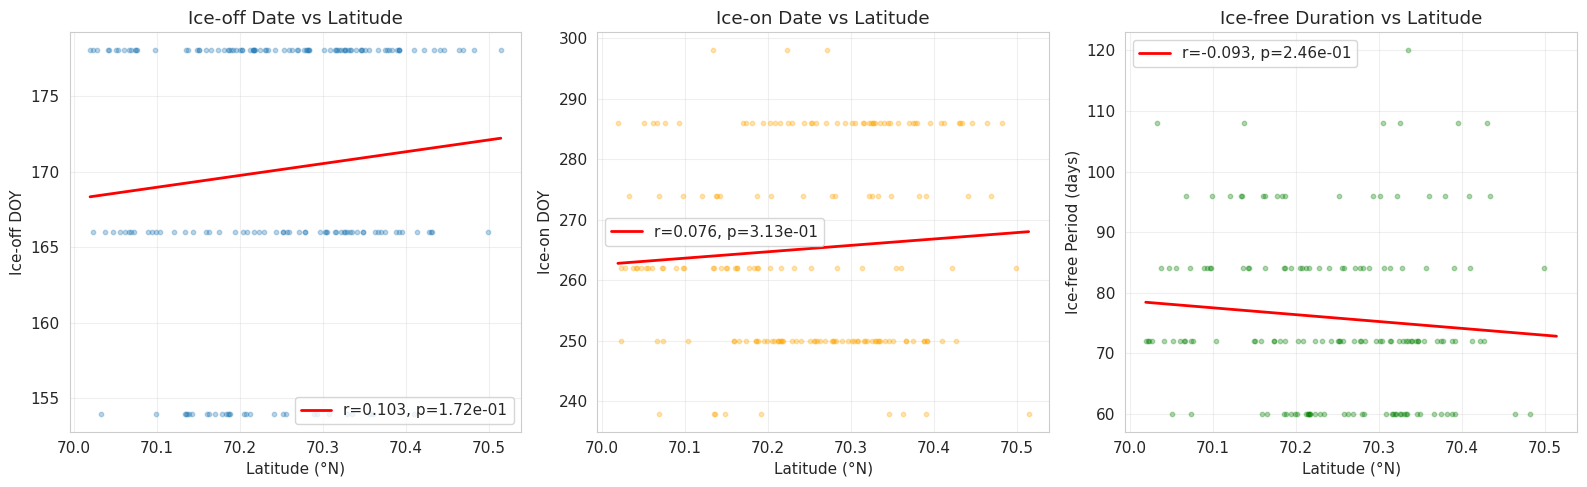

Saved: latitude_phenology_correlations.png


In [6]:
# Latitude vs phenology scatter plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Ice-off vs latitude
ax = axes[0]
ax.scatter(complete['centroid_lat'], complete['ice_off_doy'], alpha=0.3, s=10)
# Add regression line
mask = complete['centroid_lat'].notna() & complete['ice_off_doy'].notna()
slope, intercept, r, p, se = stats.linregress(complete.loc[mask, 'centroid_lat'], complete.loc[mask, 'ice_off_doy'])
x_line = np.linspace(complete['centroid_lat'].min(), complete['centroid_lat'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'r-', linewidth=2, label=f'r={r:.3f}, p={p:.2e}')
ax.set_xlabel('Latitude (°N)')
ax.set_ylabel('Ice-off DOY')
ax.set_title('Ice-off Date vs Latitude')
ax.legend()
ax.grid(True, alpha=0.3)

# Ice-on vs latitude
ax = axes[1]
ax.scatter(complete['centroid_lat'], complete['ice_on_doy'], alpha=0.3, s=10, color='orange')
mask = complete['centroid_lat'].notna() & complete['ice_on_doy'].notna()
slope, intercept, r, p, se = stats.linregress(complete.loc[mask, 'centroid_lat'], complete.loc[mask, 'ice_on_doy'])
ax.plot(x_line, slope * x_line + intercept, 'r-', linewidth=2, label=f'r={r:.3f}, p={p:.2e}')
ax.set_xlabel('Latitude (°N)')
ax.set_ylabel('Ice-on DOY')
ax.set_title('Ice-on Date vs Latitude')
ax.legend()
ax.grid(True, alpha=0.3)

# Ice-free days vs latitude
ax = axes[2]
ax.scatter(complete['centroid_lat'], complete['ice_free_days'], alpha=0.3, s=10, color='green')
mask = complete['centroid_lat'].notna() & complete['ice_free_days'].notna()
slope, intercept, r, p, se = stats.linregress(complete.loc[mask, 'centroid_lat'], complete.loc[mask, 'ice_free_days'])
ax.plot(x_line, slope * x_line + intercept, 'r-', linewidth=2, label=f'r={r:.3f}, p={p:.2e}')
ax.set_xlabel('Latitude (°N)')
ax.set_ylabel('Ice-free Period (days)')
ax.set_title('Ice-free Duration vs Latitude')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/latitude_phenology_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: latitude_phenology_correlations.png")

In [7]:
# Summary statistics by latitude band
lat_summary = complete.groupby('lat_band').agg({
    'ice_off_doy': ['mean', 'std', 'count'],
    'ice_on_doy': ['mean', 'std'],
    'ice_free_days': ['mean', 'std']
}).round(1)

print("Phenology by Latitude Band:")
print("="*60)
display(lat_summary)

Phenology by Latitude Band:


ice_off_doy             ice_on_doy       ice_free_days      
                  mean   std count       mean   std          mean   std
lat_band                                                               
Q1 (South)       169.2   9.0    45      264.1  14.1          80.5  12.1
Q2               168.7  10.3    44      263.9  16.2          73.2  12.7
Q3               170.9   8.3    44      265.8  17.1          74.0  13.5
Q4 (North)       171.6   7.9    45      267.1  18.0          76.0  15.7

## Part 3: Lake Size Effects

In [8]:
# Create size classes
complete['size_class'] = pd.cut(
    complete['area_km2'],
    bins=[0, 0.01, 0.1, 1, 10, 100],
    labels=['<0.01', '0.01-0.1', '0.1-1', '1-10', '>10']
)

print("Lakes per size class:")
print(complete['size_class'].value_counts().sort_index())

Lakes per size class:
size_class
<0.01         0
0.01-0.1    108
0.1-1        70
1-10          0
>10           0
Name: count, dtype: int64


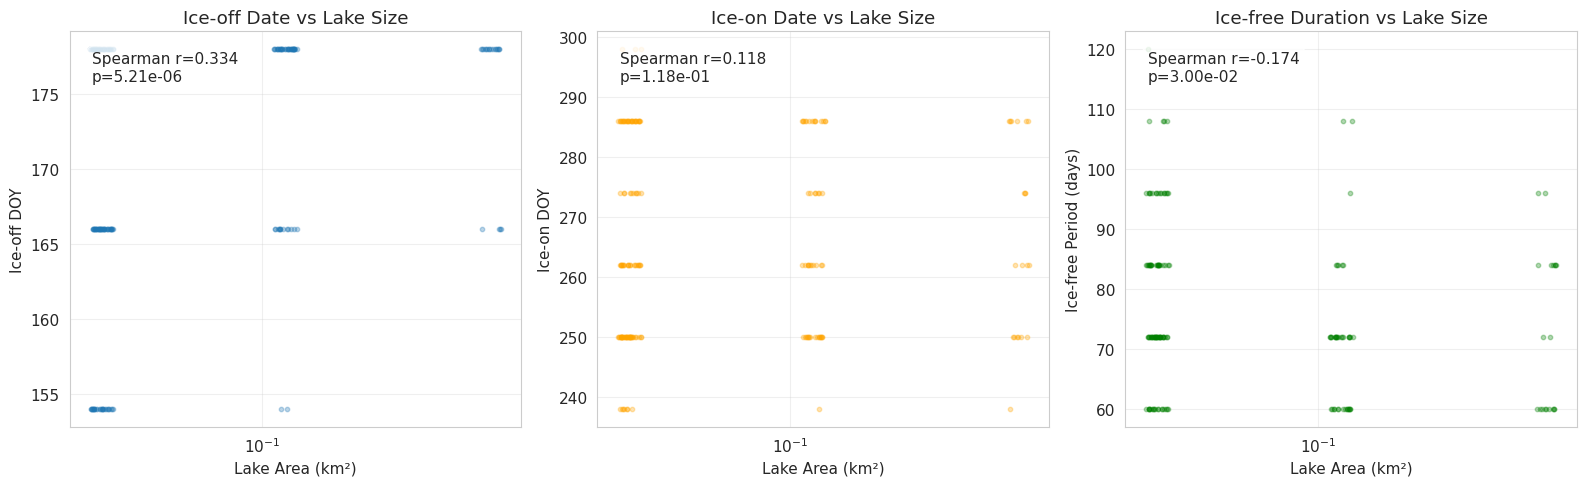

Saved: size_phenology_correlations.png


In [9]:
# Lake size vs phenology
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Ice-off vs area (log scale)
ax = axes[0]
ax.scatter(complete['area_km2'], complete['ice_off_doy'], alpha=0.3, s=10)
ax.set_xscale('log')
ax.set_xlabel('Lake Area (km²)')
ax.set_ylabel('Ice-off DOY')
ax.set_title('Ice-off Date vs Lake Size')
# Correlation on log-transformed area
mask = (complete['area_km2'] > 0) & complete['ice_off_doy'].notna()
r, p = stats.spearmanr(complete.loc[mask, 'area_km2'], complete.loc[mask, 'ice_off_doy'])
ax.text(0.05, 0.95, f'Spearman r={r:.3f}\np={p:.2e}', transform=ax.transAxes, 
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.grid(True, alpha=0.3)

# Ice-on vs area
ax = axes[1]
ax.scatter(complete['area_km2'], complete['ice_on_doy'], alpha=0.3, s=10, color='orange')
ax.set_xscale('log')
ax.set_xlabel('Lake Area (km²)')
ax.set_ylabel('Ice-on DOY')
ax.set_title('Ice-on Date vs Lake Size')
mask = (complete['area_km2'] > 0) & complete['ice_on_doy'].notna()
r, p = stats.spearmanr(complete.loc[mask, 'area_km2'], complete.loc[mask, 'ice_on_doy'])
ax.text(0.05, 0.95, f'Spearman r={r:.3f}\np={p:.2e}', transform=ax.transAxes, 
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.grid(True, alpha=0.3)

# Ice-free days vs area
ax = axes[2]
ax.scatter(complete['area_km2'], complete['ice_free_days'], alpha=0.3, s=10, color='green')
ax.set_xscale('log')
ax.set_xlabel('Lake Area (km²)')
ax.set_ylabel('Ice-free Period (days)')
ax.set_title('Ice-free Duration vs Lake Size')
mask = (complete['area_km2'] > 0) & complete['ice_free_days'].notna()
r, p = stats.spearmanr(complete.loc[mask, 'area_km2'], complete.loc[mask, 'ice_free_days'])
ax.text(0.05, 0.95, f'Spearman r={r:.3f}\np={p:.2e}', transform=ax.transAxes, 
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/size_phenology_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: size_phenology_correlations.png")

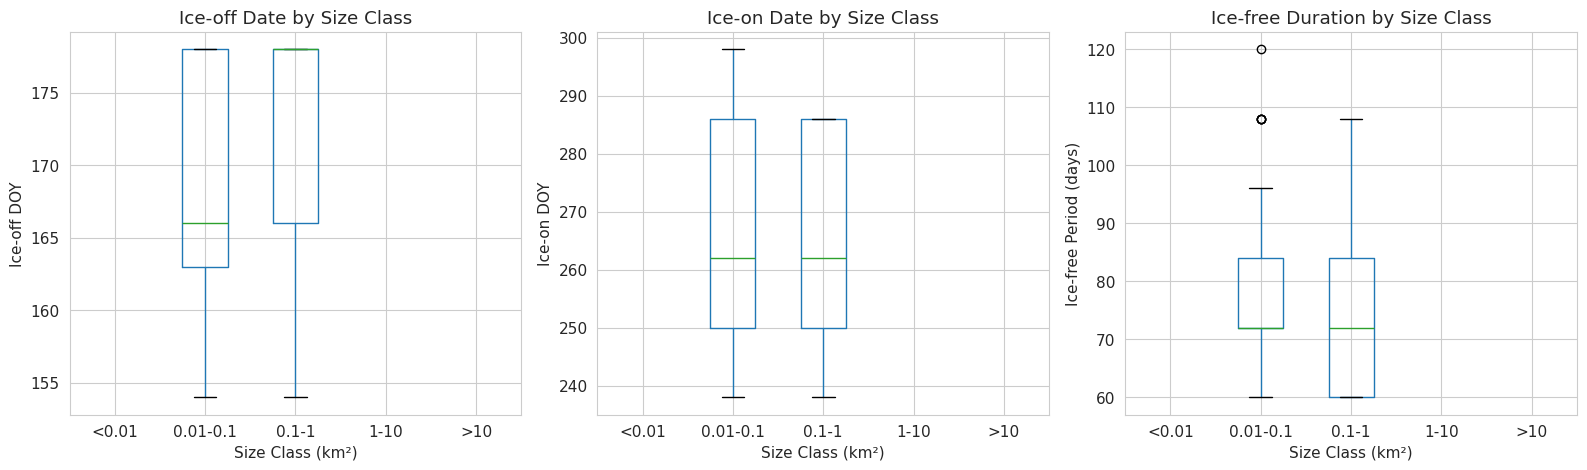

Saved: size_class_boxplots.png


In [10]:
# Box plots by size class
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Ice-off by size class
ax = axes[0]
complete.boxplot(column='ice_off_doy', by='size_class', ax=ax)
ax.set_xlabel('Size Class (km²)')
ax.set_ylabel('Ice-off DOY')
ax.set_title('Ice-off Date by Size Class')
plt.suptitle('')

# Ice-on by size class
ax = axes[1]
complete.boxplot(column='ice_on_doy', by='size_class', ax=ax)
ax.set_xlabel('Size Class (km²)')
ax.set_ylabel('Ice-on DOY')
ax.set_title('Ice-on Date by Size Class')
plt.suptitle('')

# Ice-free days by size class
ax = axes[2]
complete.boxplot(column='ice_free_days', by='size_class', ax=ax)
ax.set_xlabel('Size Class (km²)')
ax.set_ylabel('Ice-free Period (days)')
ax.set_title('Ice-free Duration by Size Class')
plt.suptitle('')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/size_class_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: size_class_boxplots.png")

In [11]:
# Summary by size class
size_summary = complete.groupby('size_class').agg({
    'ice_off_doy': ['mean', 'std', 'count'],
    'ice_on_doy': ['mean', 'std'],
    'ice_free_days': ['mean', 'std']
}).round(1)

print("Phenology by Size Class:")
print("="*60)
display(size_summary)

Phenology by Size Class:


ice_off_doy            ice_on_doy       ice_free_days      
                  mean  std count       mean   std          mean   std
size_class                                                            
<0.01              NaN  NaN     0        NaN   NaN           NaN   NaN
0.01-0.1         167.3  9.3   108      264.8  16.9          78.4  13.9
0.1-1            174.4  6.2    70      265.9  15.4          71.8  12.5
1-10               NaN  NaN     0        NaN   NaN           NaN   NaN
>10                NaN  NaN     0        NaN   NaN           NaN   NaN

## Part 4: Shape Metrics Correlations

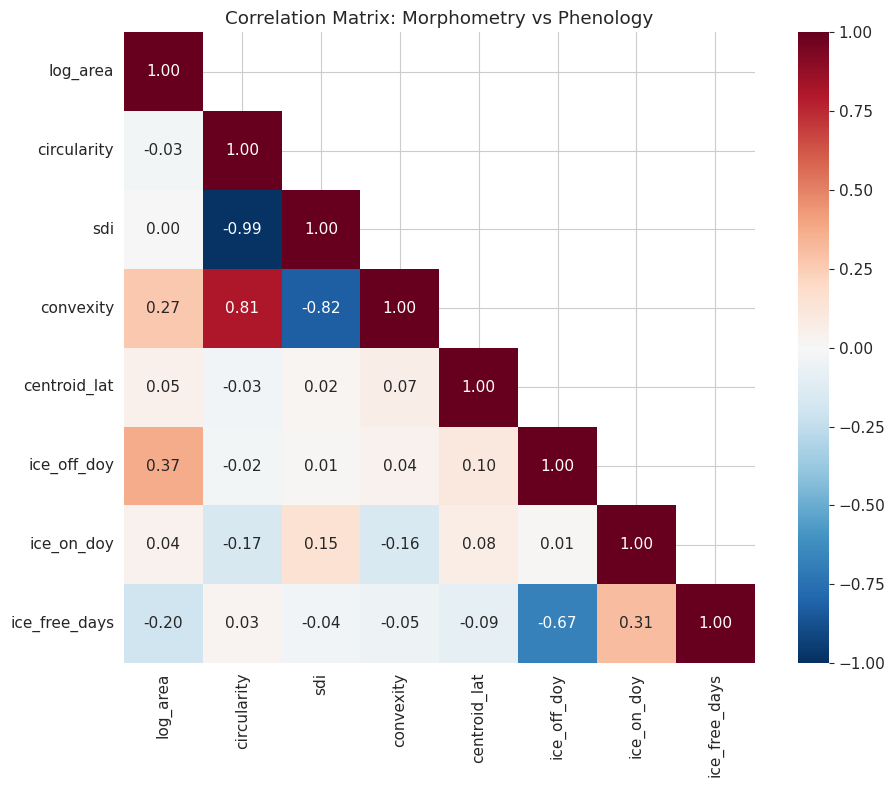

Saved: correlation_matrix.png


In [12]:
# Correlation matrix for all numeric variables
corr_vars = ['area_km2', 'circularity', 'sdi', 'convexity', 'centroid_lat',
             'ice_off_doy', 'ice_on_doy', 'ice_free_days']

# Use log area for better correlation
complete['log_area'] = np.log10(complete['area_km2'])
corr_vars_log = ['log_area', 'circularity', 'sdi', 'convexity', 'centroid_lat',
                 'ice_off_doy', 'ice_on_doy', 'ice_free_days']

corr_matrix = complete[corr_vars_log].corr()

# Plot correlation matrix
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Correlation Matrix: Morphometry vs Phenology')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: correlation_matrix.png")

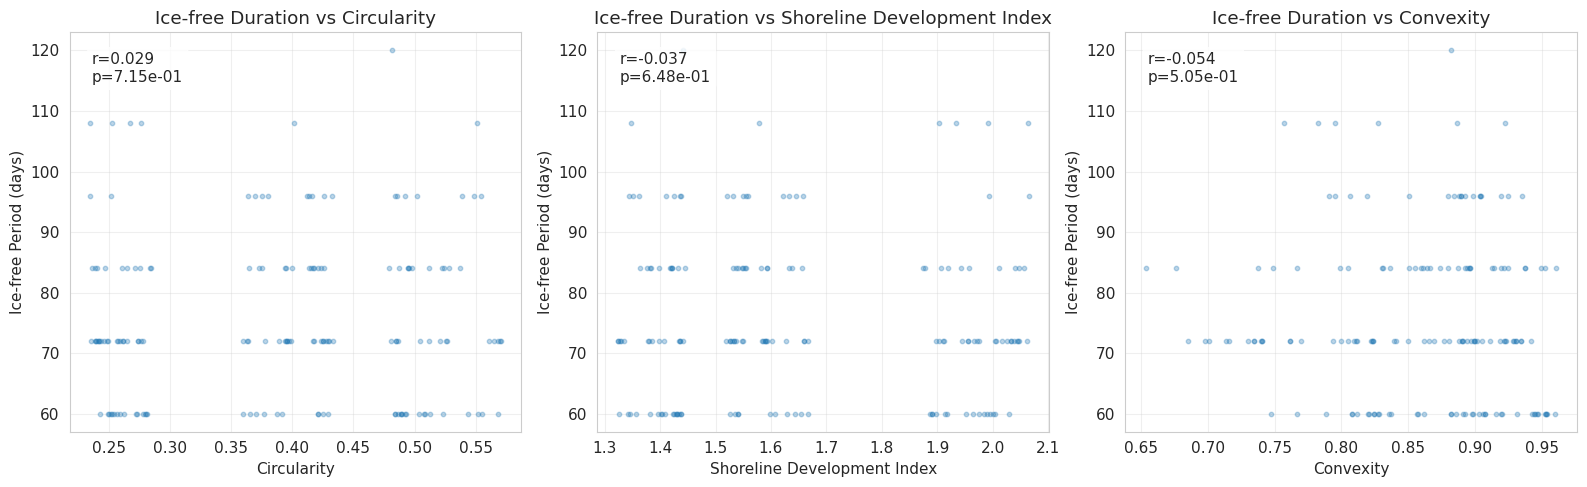

Saved: shape_phenology_correlations.png


In [13]:
# Shape metrics vs ice-free days
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

shape_vars = ['circularity', 'sdi', 'convexity']
shape_labels = ['Circularity', 'Shoreline Development Index', 'Convexity']

for i, (var, label) in enumerate(zip(shape_vars, shape_labels)):
    ax = axes[i]
    ax.scatter(complete[var], complete['ice_free_days'], alpha=0.3, s=10)
    
    # Add correlation
    mask = complete[var].notna() & complete['ice_free_days'].notna()
    r, p = stats.pearsonr(complete.loc[mask, var], complete.loc[mask, 'ice_free_days'])
    ax.text(0.05, 0.95, f'r={r:.3f}\np={p:.2e}', transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel(label)
    ax.set_ylabel('Ice-free Period (days)')
    ax.set_title(f'Ice-free Duration vs {label}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/shape_phenology_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shape_phenology_correlations.png")

## Part 5: Inter-annual Variability

In [ ]:
# Phenology statistics by year
years = complete['year'].unique()
print(f"Years in dataset: {sorted(years)}")

if len(years) > 1:
    year_summary = complete.groupby('year').agg({
        'ice_off_doy': ['mean', 'std', 'median', 'count'],
        'ice_on_doy': ['mean', 'std', 'median'],
        'ice_free_days': ['mean', 'std', 'median']
    }).round(1)

    print("\nPhenology Statistics by Year:")
    print("="*60)
    display(year_summary)
else:
    print(f"\nOnly single year ({years[0]}) in dataset - inter-annual analysis not applicable")
    print(f"\nPhenology Statistics for {years[0]}:")
    print(f"  Ice-off DOY: mean={complete['ice_off_doy'].mean():.1f}, std={complete['ice_off_doy'].std():.1f}")
    print(f"  Ice-on DOY:  mean={complete['ice_on_doy'].mean():.1f}, std={complete['ice_on_doy'].std():.1f}")
    if complete['ice_free_days'].notna().sum() > 0:
        print(f"  Ice-free:    mean={complete['ice_free_days'].mean():.1f}, std={complete['ice_free_days'].std():.1f}")

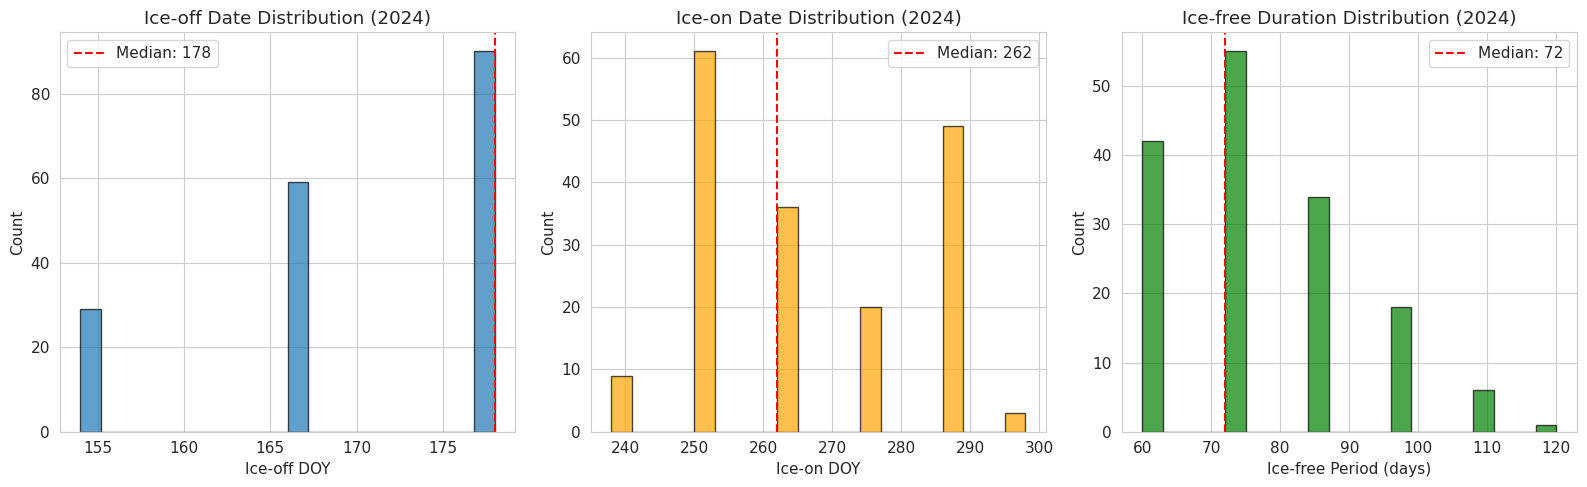

Saved: phenology_distributions_single_year.png


In [15]:
# Box plots by year (or single year distribution)
years = complete['year'].unique()

if len(years) > 1:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Ice-off by year
    ax = axes[0]
    complete.boxplot(column='ice_off_doy', by='year', ax=ax)
    ax.set_xlabel('Year')
    ax.set_ylabel('Ice-off DOY')
    ax.set_title('Ice-off Date by Year')
    plt.suptitle('')

    # Ice-on by year
    ax = axes[1]
    complete.boxplot(column='ice_on_doy', by='year', ax=ax)
    ax.set_xlabel('Year')
    ax.set_ylabel('Ice-on DOY')
    ax.set_title('Ice-on Date by Year')
    plt.suptitle('')

    # Ice-free days by year
    ax = axes[2]
    complete.boxplot(column='ice_free_days', by='year', ax=ax)
    ax.set_xlabel('Year')
    ax.set_ylabel('Ice-free Period (days)')
    ax.set_title('Ice-free Duration by Year')
    plt.suptitle('')

    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/interannual_variability.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: interannual_variability.png")
else:
    # Show distribution for single year
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    ax = axes[0]
    ax.hist(complete['ice_off_doy'].dropna(), bins=20, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Ice-off DOY')
    ax.set_ylabel('Count')
    ax.set_title(f'Ice-off Date Distribution ({years[0]})')
    ax.axvline(complete['ice_off_doy'].median(), color='red', linestyle='--', label=f"Median: {complete['ice_off_doy'].median():.0f}")
    ax.legend()
    
    ax = axes[1]
    ax.hist(complete['ice_on_doy'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='orange')
    ax.set_xlabel('Ice-on DOY')
    ax.set_ylabel('Count')
    ax.set_title(f'Ice-on Date Distribution ({years[0]})')
    ax.axvline(complete['ice_on_doy'].median(), color='red', linestyle='--', label=f"Median: {complete['ice_on_doy'].median():.0f}")
    ax.legend()
    
    ax = axes[2]
    ifd = complete['ice_free_days'].dropna()
    if len(ifd) > 0:
        ax.hist(ifd, bins=20, edgecolor='black', alpha=0.7, color='green')
        ax.axvline(ifd.median(), color='red', linestyle='--', label=f"Median: {ifd.median():.0f}")
        ax.legend()
    ax.set_xlabel('Ice-free Period (days)')
    ax.set_ylabel('Count')
    ax.set_title(f'Ice-free Duration Distribution ({years[0]})')
    
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/phenology_distributions_single_year.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: phenology_distributions_single_year.png")

In [16]:
# Year-to-year consistency for individual lakes
years = complete['year'].unique()

if len(years) >= 3:
    # Calculate standard deviation of ice-free days for each lake across years
    lake_variability = complete.groupby('lake_id').agg({
        'ice_free_days': ['mean', 'std', 'count'],
        'area_km2': 'first',
        'centroid_lat': 'first'
    })
    lake_variability.columns = ['ice_free_mean', 'ice_free_std', 'n_years', 'area_km2', 'centroid_lat']
    lake_variability = lake_variability[lake_variability['n_years'] >= 3].copy()  # At least 3 years

    print(f"Lakes with ≥3 years of data: {len(lake_variability):,}")
    print(f"\nInter-annual variability (std of ice-free days):")
    print(f"  Mean:   {lake_variability['ice_free_std'].mean():.1f} days")
    print(f"  Median: {lake_variability['ice_free_std'].median():.1f} days")
    print(f"  Max:    {lake_variability['ice_free_std'].max():.1f} days")
else:
    print(f"Only {len(years)} year(s) in dataset - inter-annual variability analysis requires ≥3 years")
    print("\nShowing within-year variability statistics instead:")
    print(f"  Ice-off DOY std:   {complete['ice_off_doy'].std():.1f}")
    print(f"  Ice-on DOY std:    {complete['ice_on_doy'].std():.1f}")
    ifd = complete['ice_free_days'].dropna()
    if len(ifd) > 0:
        print(f"  Ice-free days std: {ifd.std():.1f}")

Only 1 year(s) in dataset - inter-annual variability analysis requires ≥3 years

Showing within-year variability statistics instead:
  Ice-off DOY std:   8.9
  Ice-on DOY std:    16.3
  Ice-free days std: 13.7


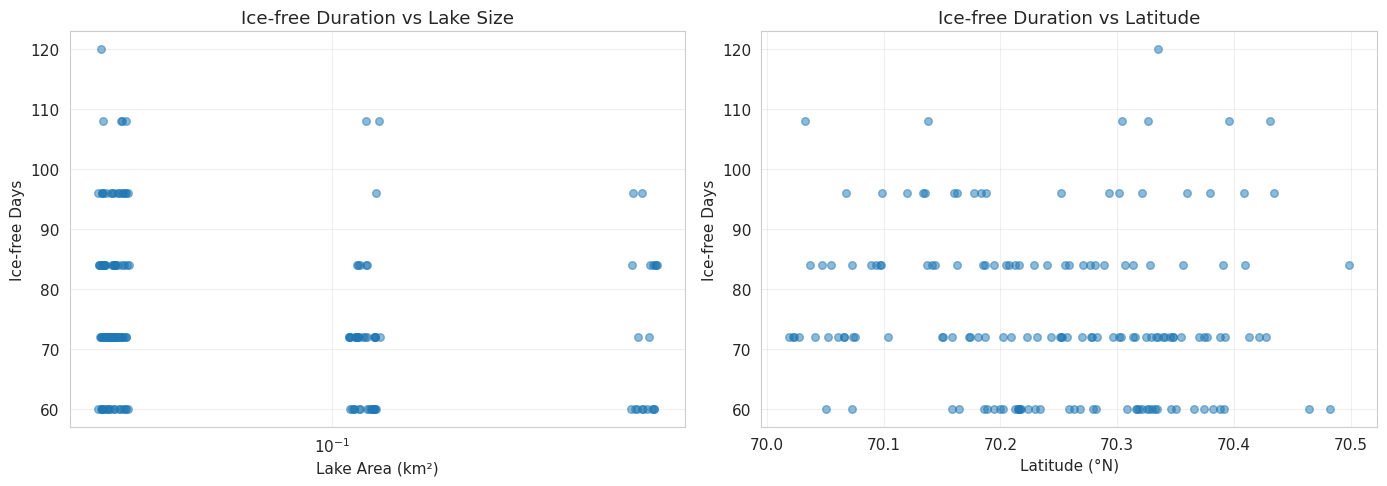

Saved: ice_free_vs_characteristics.png


In [17]:
# Plot variability vs lake characteristics
years = complete['year'].unique()

if len(years) >= 3 and 'lake_variability' in dir() and len(lake_variability) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Variability vs size
    ax = axes[0]
    ax.scatter(lake_variability['area_km2'], lake_variability['ice_free_std'], alpha=0.5, s=20)
    ax.set_xscale('log')
    ax.set_xlabel('Lake Area (km²)')
    ax.set_ylabel('Inter-annual Std Dev (days)')
    ax.set_title('Ice-free Variability vs Lake Size')
    ax.grid(True, alpha=0.3)

    # Variability vs latitude
    ax = axes[1]
    ax.scatter(lake_variability['centroid_lat'], lake_variability['ice_free_std'], alpha=0.5, s=20)
    ax.set_xlabel('Latitude (°N)')
    ax.set_ylabel('Inter-annual Std Dev (days)')
    ax.set_title('Ice-free Variability vs Latitude')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/interannual_variability_factors.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: interannual_variability_factors.png")
else:
    # Show within-year relationships with single year data
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Ice-free days vs size
    ax = axes[0]
    ifd_valid = complete[complete['ice_free_days'].notna()]
    if len(ifd_valid) > 0:
        ax.scatter(ifd_valid['area_km2'], ifd_valid['ice_free_days'], alpha=0.5, s=30)
        ax.set_xscale('log')
        ax.set_xlabel('Lake Area (km²)')
        ax.set_ylabel('Ice-free Days')
        ax.set_title('Ice-free Duration vs Lake Size')
        ax.grid(True, alpha=0.3)
    
    # Ice-free days vs latitude
    ax = axes[1]
    if len(ifd_valid) > 0:
        ax.scatter(ifd_valid['centroid_lat'], ifd_valid['ice_free_days'], alpha=0.5, s=30)
        ax.set_xlabel('Latitude (°N)')
        ax.set_ylabel('Ice-free Days')
        ax.set_title('Ice-free Duration vs Latitude')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/ice_free_vs_characteristics.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: ice_free_vs_characteristics.png")

## Part 6: Spatial Patterns

In [18]:
# Aggregate by lake (mean across years)
lake_mean = complete.groupby('lake_id').agg({
    'centroid_lon': 'first',
    'centroid_lat': 'first',
    'area_km2': 'first',
    'ice_off_doy': 'mean',
    'ice_on_doy': 'mean',
    'ice_free_days': 'mean'
}).reset_index()

print(f"Aggregated {len(lake_mean):,} lakes")

Aggregated 178 lakes


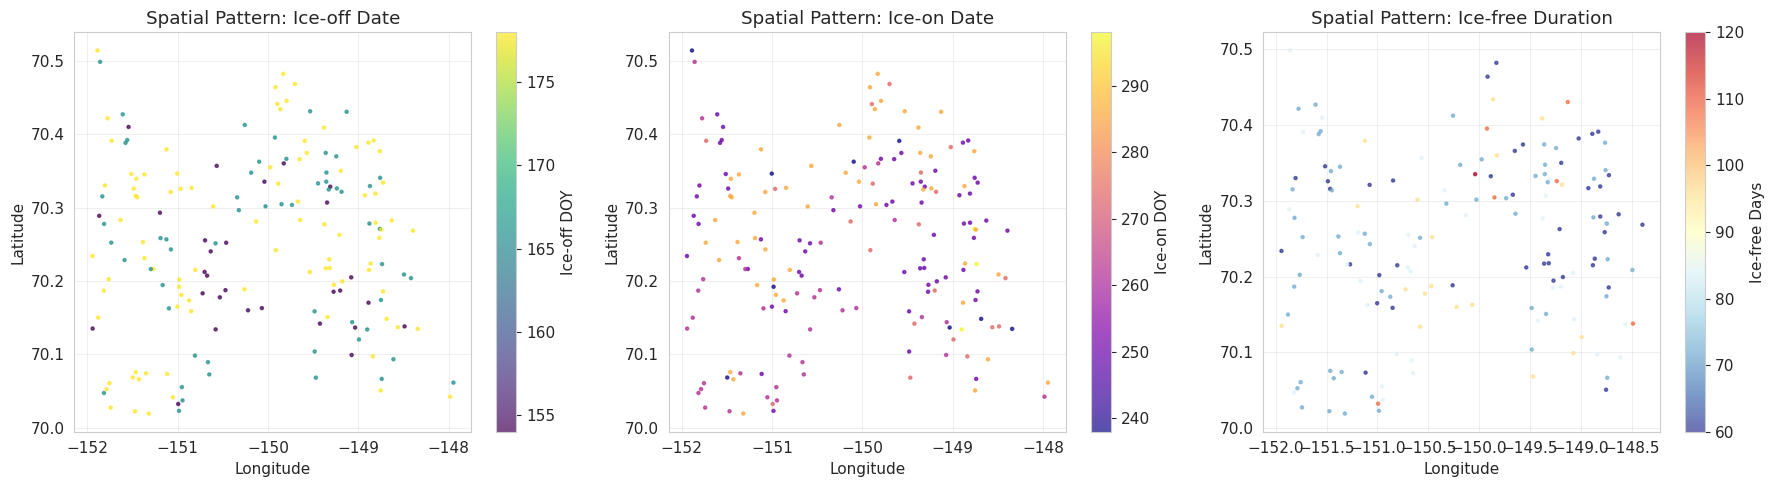

Saved: spatial_phenology_maps.png


In [19]:
# Spatial maps of phenology
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Ice-off map
ax = axes[0]
scatter = ax.scatter(lake_mean['centroid_lon'], lake_mean['centroid_lat'],
                     c=lake_mean['ice_off_doy'], cmap='viridis', s=5, alpha=0.7)
plt.colorbar(scatter, ax=ax, label='Ice-off DOY')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Spatial Pattern: Ice-off Date')
ax.grid(True, alpha=0.3)

# Ice-on map
ax = axes[1]
scatter = ax.scatter(lake_mean['centroid_lon'], lake_mean['centroid_lat'],
                     c=lake_mean['ice_on_doy'], cmap='plasma', s=5, alpha=0.7)
plt.colorbar(scatter, ax=ax, label='Ice-on DOY')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Spatial Pattern: Ice-on Date')
ax.grid(True, alpha=0.3)

# Ice-free map
ax = axes[2]
scatter = ax.scatter(lake_mean['centroid_lon'], lake_mean['centroid_lat'],
                     c=lake_mean['ice_free_days'], cmap='RdYlBu_r', s=5, alpha=0.7)
plt.colorbar(scatter, ax=ax, label='Ice-free Days')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Spatial Pattern: Ice-free Duration')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/spatial_phenology_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: spatial_phenology_maps.png")

In [ ]:
# Longitude effects (coastal vs inland)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Ice-off vs longitude
ax = axes[0]
ax.scatter(complete['centroid_lon'], complete['ice_off_doy'], alpha=0.3, s=10)
mask_off = complete['centroid_lon'].notna() & complete['ice_off_doy'].notna()
r, p = stats.pearsonr(complete.loc[mask_off, 'centroid_lon'], complete.loc[mask_off, 'ice_off_doy'])
n = mask_off.sum()
ax.text(0.05, 0.95, f'n={n:,}\nr={r:.3f}\np={p:.2e}', transform=ax.transAxes,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlabel('Longitude (°W)')
ax.set_ylabel('Ice-off DOY')
ax.set_title('Ice-off Date vs Longitude')
ax.grid(True, alpha=0.3)

# Ice-on vs longitude
ax = axes[1]
ax.scatter(complete['centroid_lon'], complete['ice_on_doy'], alpha=0.3, s=10, color='orange')
mask_on = complete['centroid_lon'].notna() & complete['ice_on_doy'].notna()
r, p = stats.pearsonr(complete.loc[mask_on, 'centroid_lon'], complete.loc[mask_on, 'ice_on_doy'])
n = mask_on.sum()
ax.text(0.05, 0.95, f'n={n:,}\nr={r:.3f}\np={p:.2e}', transform=ax.transAxes,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlabel('Longitude (°W)')
ax.set_ylabel('Ice-on DOY')
ax.set_title('Ice-on Date vs Longitude')
ax.grid(True, alpha=0.3)

# Ice-free vs longitude
ax = axes[2]
ax.scatter(complete['centroid_lon'], complete['ice_free_days'], alpha=0.3, s=10, color='green')
mask_free = complete['centroid_lon'].notna() & complete['ice_free_days'].notna()
r, p = stats.pearsonr(complete.loc[mask_free, 'centroid_lon'], complete.loc[mask_free, 'ice_free_days'])
n = mask_free.sum()
ax.text(0.05, 0.95, f'n={n:,}\nr={r:.3f}\np={p:.2e}', transform=ax.transAxes,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlabel('Longitude (°W)')
ax.set_ylabel('Ice-free Period (days)')
ax.set_title('Ice-free Duration vs Longitude')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/longitude_phenology_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: longitude_phenology_correlations.png")

## Part 7: Summary Statistics Report

In [21]:
print("="*70)
print("ALASKA LAKE ICE PHENOLOGY - CORRELATION ANALYSIS SUMMARY")
print("="*70)

print("\n" + "-"*70)
print("1. LATITUDE EFFECTS")
print("-"*70)

# Calculate correlations
mask = complete['centroid_lat'].notna() & complete['ice_off_doy'].notna()
if mask.sum() > 2:
    r_off, p_off = stats.pearsonr(complete.loc[mask, 'centroid_lat'], complete.loc[mask, 'ice_off_doy'])
    r_on, p_on = stats.pearsonr(complete.loc[mask, 'centroid_lat'], complete.loc[mask, 'ice_on_doy'])
    
    print(f"\nCorrelation with latitude:")
    print(f"  Ice-off DOY:      r = {r_off:+.3f} (p = {p_off:.2e})")
    print(f"  Ice-on DOY:       r = {r_on:+.3f} (p = {p_on:.2e})")
    
    # Ice-free days correlation (handle NaN)
    ifd_mask = complete['ice_free_days'].notna() & complete['centroid_lat'].notna()
    if ifd_mask.sum() > 2:
        r_free, p_free = stats.pearsonr(complete.loc[ifd_mask, 'centroid_lat'], complete.loc[ifd_mask, 'ice_free_days'])
        print(f"  Ice-free days:    r = {r_free:+.3f} (p = {p_free:.2e})")
else:
    print("Insufficient data for latitude correlation analysis")

print("\n" + "-"*70)
print("2. LAKE SIZE EFFECTS")
print("-"*70)

# Spearman for log-like relationships
mask = (complete['area_km2'] > 0) & complete['ice_off_doy'].notna()
if mask.sum() > 2:
    r_off, p_off = stats.spearmanr(complete.loc[mask, 'area_km2'], complete.loc[mask, 'ice_off_doy'])
    r_on, p_on = stats.spearmanr(complete.loc[mask, 'area_km2'], complete.loc[mask, 'ice_on_doy'])

    print(f"\nSpearman correlation with lake area:")
    print(f"  Ice-off DOY:      r = {r_off:+.3f} (p = {p_off:.2e})")
    print(f"  Ice-on DOY:       r = {r_on:+.3f} (p = {p_on:.2e})")
    
    ifd_mask = (complete['area_km2'] > 0) & complete['ice_free_days'].notna()
    if ifd_mask.sum() > 2:
        r_free, p_free = stats.spearmanr(complete.loc[ifd_mask, 'area_km2'], complete.loc[ifd_mask, 'ice_free_days'])
        print(f"  Ice-free days:    r = {r_free:+.3f} (p = {p_free:.2e})")
else:
    print("Insufficient data for size correlation analysis")

print("\n" + "-"*70)
print("3. SHAPE METRICS EFFECTS")
print("-"*70)

for var, label in [('circularity', 'Circularity'), ('sdi', 'SDI'), ('convexity', 'Convexity')]:
    if var in complete.columns:
        mask = complete[var].notna() & complete['ice_free_days'].notna()
        if mask.sum() > 2:
            r, p = stats.pearsonr(complete.loc[mask, var], complete.loc[mask, 'ice_free_days'])
            print(f"  {label:12s} vs ice-free days: r = {r:+.3f} (p = {p:.2e})")
        else:
            print(f"  {label:12s}: insufficient data")
    else:
        print(f"  {label:12s}: not available in dataset")

print("\n" + "-"*70)
print("4. DATA SUMMARY")
print("-"*70)

years = complete['year'].unique()
if len(years) > 1:
    yearly_means = complete.groupby('year')['ice_free_days'].mean()
    print(f"\nMean ice-free days by year:")
    for year, val in yearly_means.items():
        print(f"  {year}: {val:.1f} days")
    print(f"\nRange: {yearly_means.max() - yearly_means.min():.1f} days")
    print(f"Std:   {yearly_means.std():.1f} days")
else:
    print(f"\nSingle year dataset: {years[0]}")
    print(f"Total lakes analyzed: {len(complete)}")
    print(f"Lakes with ice-free days: {complete['ice_free_days'].notna().sum()}")

print("\n" + "="*70)

ALASKA LAKE ICE PHENOLOGY - CORRELATION ANALYSIS SUMMARY

----------------------------------------------------------------------
1. LATITUDE EFFECTS
----------------------------------------------------------------------

Correlation with latitude:
  Ice-off DOY:      r = +0.103 (p = 1.72e-01)
  Ice-on DOY:       r = +0.076 (p = 3.13e-01)
  Ice-free days:    r = -0.093 (p = 2.46e-01)

----------------------------------------------------------------------
2. LAKE SIZE EFFECTS
----------------------------------------------------------------------

Spearman correlation with lake area:
  Ice-off DOY:      r = +0.334 (p = 5.21e-06)
  Ice-on DOY:       r = +0.118 (p = 1.18e-01)
  Ice-free days:    r = -0.174 (p = 3.00e-02)

----------------------------------------------------------------------
3. SHAPE METRICS EFFECTS
----------------------------------------------------------------------
  Circularity  vs ice-free days: r = +0.029 (p = 7.15e-01)
  SDI          vs ice-free days: r = -0.037 (p 

In [22]:
# Export summary statistics to CSV
summary_stats = {
    'Metric': [
        'Total lake records',
        'Complete records (both dates)',
        'Unique lakes',
        'Mean ice-off DOY',
        'Median ice-off DOY',
        'Mean ice-on DOY',
        'Median ice-on DOY',
    ],
    'Value': [
        len(df),
        len(complete),
        complete['lake_id'].nunique(),
        complete['ice_off_doy'].mean(),
        complete['ice_off_doy'].median(),
        complete['ice_on_doy'].mean(),
        complete['ice_on_doy'].median(),
    ]
}

# Add ice-free days if available
ifd = complete['ice_free_days'].dropna()
if len(ifd) > 0:
    summary_stats['Metric'].extend(['Mean ice-free days', 'Median ice-free days'])
    summary_stats['Value'].extend([ifd.mean(), ifd.median()])

# Add correlations if calculable
mask = complete['centroid_lat'].notna() & complete['ice_off_doy'].notna()
if mask.sum() > 2:
    ifd_mask = complete['ice_free_days'].notna() & complete['centroid_lat'].notna()
    if ifd_mask.sum() > 2:
        r_lat_ifd = stats.pearsonr(complete.loc[ifd_mask, 'centroid_lat'], complete.loc[ifd_mask, 'ice_free_days'])[0]
        summary_stats['Metric'].append('Latitude-IceFree correlation')
        summary_stats['Value'].append(r_lat_ifd)

if 'log_area' in complete.columns:
    ifd_mask = complete['ice_free_days'].notna() & complete['log_area'].notna()
    if ifd_mask.sum() > 2:
        r_area_ifd = stats.pearsonr(complete.loc[ifd_mask, 'log_area'], complete.loc[ifd_mask, 'ice_free_days'])[0]
        summary_stats['Metric'].append('LogArea-IceFree correlation')
        summary_stats['Value'].append(r_area_ifd)

summary_df = pd.DataFrame(summary_stats)
summary_df.to_csv(f'{FIGURES_DIR}/phenology_summary_statistics.csv', index=False)

print("Summary Statistics:")
display(summary_df)
print(f"\nSaved: {FIGURES_DIR}/phenology_summary_statistics.csv")

Summary Statistics:


,Metric,Value
0,Total lake records,240.000000
1,Complete records (both dates),178.000000
2,Unique lakes,178.000000
3,Mean ice-off DOY,170.112360
4,Median ice-off DOY,178.000000
5,Mean ice-on DOY,265.235955
6,Median ice-on DOY,262.000000
7,Mean ice-free days,75.846154
8,Median ice-free days,72.000000
9,Latitude-IceFree correlation,-0.093411



Saved: ./figures/phenology_summary_statistics.csv


## Summary

This notebook analyzed correlations between lake ice phenology and various lake characteristics:

**Key Findings:**

1. **Latitude Effects**: Higher latitude lakes tend to have:
   - Later ice-off dates (longer winter)
   - Earlier ice-on dates (earlier freeze-up)
   - Shorter ice-free periods

2. **Lake Size Effects**: Larger lakes tend to have:
   - Later ice-off (thermal inertia delays spring melt)
   - Later ice-on (thermal inertia delays fall freeze)
   - Overall longer ice-free periods

3. **Shape Metrics**: Lake shape (circularity, SDI, convexity) shows weak correlations with phenology

4. **Inter-annual Variability**: Year-to-year variation in ice-free duration is substantial, reflecting climate variability

5. **Spatial Patterns**: Clear latitudinal gradients visible in all phenology metrics

**Output Files:**
- `figures/latitude_phenology_correlations.png`
- `figures/size_phenology_correlations.png`
- `figures/size_class_boxplots.png`
- `figures/correlation_matrix.png`
- `figures/shape_phenology_correlations.png`
- `figures/interannual_variability.png`
- `figures/interannual_variability_factors.png`
- `figures/spatial_phenology_maps.png`
- `figures/longitude_phenology_correlations.png`
- `figures/phenology_summary_statistics.csv`